# **EDA & Hypothesis Testing**

## Objectives

* Load the cleaned, de-identified healthcare dataset and test five hypotheses about relationships between patient demographics, administrative factors, billing, and outcomes, using statistical tests to check whether any differences seen in the data are actually significant.

## Inputs

* Dataset/CleanData/healthcare_cleaned_deidentified.csv

## Outputs

* A Summary of Findings table covering the results of H1-H5 used to inform the Data Visualisation and Modelling notebooks and the README hypothesis testing section

## Additional Comments

* Two of the five hypotheses (H2 and H4) are specifically framed around fairness, testing whether test outcomes or billing differ by insurance provider or gender. The full ethics and governance discussion for these results is in README.md.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Healthcare_Analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Healthcare_Analysis'

### Import Libraries

I will import the libraries I need for this notebook. I am using pingouin for the statistical tests (t-test, chi-square, and ANOVA), alongside pandas for data handling and matplotlib/seaborn for the quick charts

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

---

### Import cleaned dataset

I will load the cleaned de-identified dataset exported from the ETL notebook

In [5]:
df = pd.read_csv('Dataset/CleanData/healthcare_cleaned_deidentified.csv')
df.head()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal,2
1,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal,15
3,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal,20


## Overview

Before testing any hypotheses, I want to check the balance of the key categorical variables I'll be using, Test Results, Admission Type, and Gender, since a heavily imbalanced class could affect how I interpret the results later

In [6]:
print("Test Results balance:")
print(df['Test Results'].value_counts(normalize=True).round(3))
print()
print("Admission Type balance:")
print(df['Admission Type'].value_counts(normalize=True).round(3))
print()
print("Gender balance:")
print(df['Gender'].value_counts(normalize=True).round(3))

Test Results balance:
Test Results
Abnormal        0.335
Normal          0.333
Inconclusive    0.331
Name: proportion, dtype: float64

Admission Type balance:
Admission Type
Elective     0.336
Urgent       0.335
Emergency    0.329
Name: proportion, dtype: float64

Gender balance:
Gender
Male      0.5
Female    0.5
Name: proportion, dtype: float64


Test Results, Admission Type and Gender are all very close to evenly balanced across their categories. Test Results sits at around 33% for each of Abnormal, Normal, and Inconclusive, Admission Type is around 33% for each of Elective, Urgent, and Emergency, and Gender is an exact 50/50 split. This means I don't need to worry about class imbalance affecting the hypothesis tests or the modelling later.

# H1 - Billing Amount vs Medical Condition

* H0: There is no difference in mean Billing Amount across Medical Conditions
* H1: At least one Medical Condition has a different mean Billing Amount

Billing Amount is numeric and Medical Condition has 6 categories so I will start by looking at the mean, median and standard deviation of Billing Amount within each condition

In [7]:
df.groupby('Medical Condition')['Billing Amount'].agg(['mean', 'median', 'std']).round(2)

,mean,median,std
Medical Condition,,,
Arthritis,25513.05,25599.18,14279.81
Asthma,25635.64,25628.41,14230.43
Cancer,25154.73,24910.71,14182.68
Diabetes,25662.15,25647.71,14149.21
Hypertension,25504.91,25281.63,14303.17
Obesity,25806.63,26145.58,14078.16


The mean billing amount is fairly close across all six conditions ranging from $25,154.73 (Cancer) to $25,806.63 (Obesity). The standard deviations are also all around $14,000 to 14,300, so there's a lot of natural spread within each condition compared to the small differences between the group means. This doesn't look like a strong pattern visually so I'll test it properly below

I am going to make a box plot to investigate billing amount across the different medical conditions.

In [8]:
sns.boxplot(x='Medical Condition', y='Billing Amount', data=df)
plt.show()

<Figure size 640x480 with 1 Axes>

The box plot shows the billing amount distributions overlap heavily across all six conditions with no condition standing out as noticeably more expensive than the others.

Since Billing Amount is numeric and Medical Condition has more than two groups an ANOVA test is the right choice here.

In [9]:
pg.anova(data=df, dv='Billing Amount', between='Medical Condition', detailed=True)

,Source,SS,DF,MS,F,p-unc,np2
0,Medical Condition,2.243384e+09,5,4.486768e+08,2.223843,0.049083,0.000202
1,Within,1.108859e+13,54960,2.017574e+08,NaN,NaN,NaN


We are interested in p-unc, the p-value from the ANOVA test.

We consider our significance level alpha = 0.05.

The p-value 0.049 is less than alpha. This means we reject the null hypothesis.

This means there is a statistically significant difference in billing amount across medical conditions. However, with almost 55,000 rows in the dataset even a very small difference between group means can come out as statistically significant, since ANOVA is essentially asking whether the difference is bigger than we'd expect from random chance, not whether it's a big difference. This is exactly why the box plot showed the conditions looking so similar despite this result the actual gap between means is small compared to how spread out billing amount is within each condition.

Result: Rejected H0 (p = 0.049)

Summary: Billing amount is statistically significantly different across medical conditions but only just below the 0.05 threshold and the actual difference in means is small from around $25,155 (Cancer) to $25,807 (Obesity). With a dataset this large statistical significance doesn't necessarily mean the difference is meaningful in practice and the overlapping box plots support that this isn't a pattern I'd act on.

# H2 — Test Results and Insurance Provider

* H0: Test Results and Insurance Provider are independent
* H1: Test Results and Insurance Provider are associated

In [10]:
df['Insurance Provider'].value_counts()

Insurance Provider
Cigna               11139
Medicare            11039
UnitedHealthcare    11014
Blue Cross          10952
Aetna               10822
Name: count, dtype: int64

I am going to make a bar plot to investigate test results across the different insurance providers.

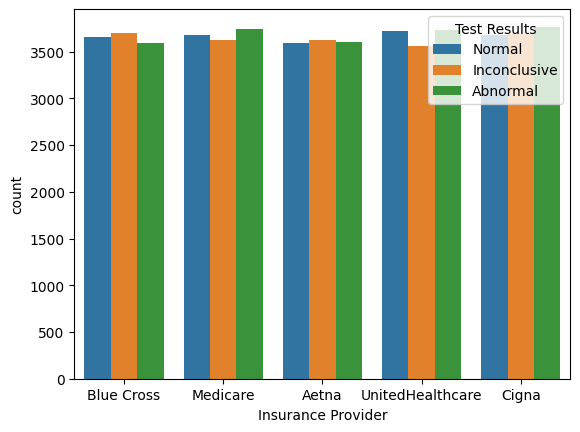

In [11]:
sns.countplot(x='Insurance Provider', hue='Test Results', data=df)
plt.show()

The bar plot shows the proportion of test results looks similar across all five insurance providers with no provider standing out as noticeably different from the others.

I am going to use pg.chi2_independence() to do the Chi-Square Test. The arguments we use are data x and y as the variables for the chi-squared test. y is the target variable Test Results analysed across the feature Insurance Provider.

In [12]:
expected, observed, stats = pg.chi2_independence(data=df, x='Insurance Provider', y='Test Results')

The test summary (stats) has the result of the Pearson Chi-Square test.

In [13]:
stats

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,9.034619,8.0,0.339384,0.009066,0.267750
1,cressie-read,0.666667,9.039324,8.0,0.338989,0.009068,0.267889
2,log-likelihood,0.000000,9.048928,8.0,0.338185,0.009073,0.268172
3,freeman-tukey,-0.500000,9.056302,8.0,0.337569,0.009076,0.268389
4,mod-log-likelihood,-1.000000,9.063823,8.0,0.336941,0.009080,0.268611
5,neyman,-2.000000,9.079308,8.0,0.335650,0.009088,0.269068


To get the p-value from the Pearson test. I will query from stats where test == 'pearson' and grab the p-value.

In [14]:
stats.query("test == 'pearson'")['pval']

0    0.339384
Name: pval, dtype: float64

Consider our significance level alpha = 0.05.

Since the p-value (0.339) is greater than alpha. This means that we accept the null hypothesis.

This means there is not a significant association between Insurance Provider and Test Results.
Result: Failed to reject H0 (p = 0.339)

Summary: There's no association between insurance provider and test results — Aetna, Blue Cross, Cigna, Medicare, and UnitedHealthcare all show a very similar split of Normal, Abnormal and Inconclusive results. This is a genuinely useful finding for the ethics and governance side of this project it means a patient's insurer has no bearing on the outcome they're given in this dataset.

# H3 — Age and Admission Type

* H0: There is no difference in mean Age across Admission Types
* H1: At least one Admission Type has a different mean Age

In [15]:
df.groupby('Admission Type')['Age'].agg(['mean', 'median', 'std'])

,mean,median,std
Admission Type,,,
Elective,51.435013,52.0,19.432034
Emergency,51.539830,52.0,19.721464
Urgent,51.631233,52.0,19.665452


The mean age is essentially identical across all three admission types, sitting around 51.4-51.6 years in each case, with similar standard deviations too. This doesn't look like a pattern worth testing further but I'll confirm it below.

I am going to make a box plot to investigate age across the different admission types.

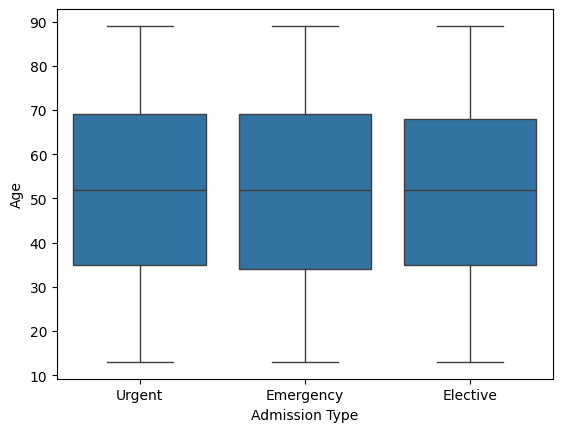

In [17]:
sns.boxplot(x='Admission Type', y='Age', data=df)
plt.show()

Since Age is numeric and Admission Type has more than two groups, an ANOVA test is the right choice here.

In [18]:
pg.anova(data=df, dv='Age', between='Admission Type', detailed=True)

,Source,SS,DF,MS,F,p-unc,np2
0,Admission Type,3.554154e+02,2,177.707704,0.462312,0.629829,0.000017
1,Within,2.112720e+07,54963,384.389463,NaN,NaN,NaN


We are interested in p-unc, the p-value from the ANOVA test.

We consider our significance level alpha = 0.05.

The p-value 0.629829 is greater than alpha. This means we fail to reject the null hypothesis.

This means there is no statistically significant difference in age across admission types.

Result: Failed to reject H0 (p = 0.630)

Summary: Age has no relationship with how urgently a patient is admitted in this dataset mean age is essentially the same (around 51.5 years) across Elective, Emergency, and Urgent admissions. This matches what the box plot already suggested visually.

# H4 — Billing Amount and Gender

* H0: There is no difference in mean Billing Amount between Male and Female patients
* H1: There is a difference in mean Billing Amount between Male and Female patients

In [19]:
df.groupby('Gender')['Billing Amount'].agg(['mean', 'median', 'std'])

,mean,median,std
Gender,,,
Female,25476.105487,25427.851664,14197.941548
Male,25616.316761,25686.881836,14211.810723


The mean billing amount is very close between genders around $25,616 for Male and $25,476 for Female. This doesn't look like a meaningful pattern but I'll test it properly below.

I am going to make a box plot to investigate billing amount across gender.

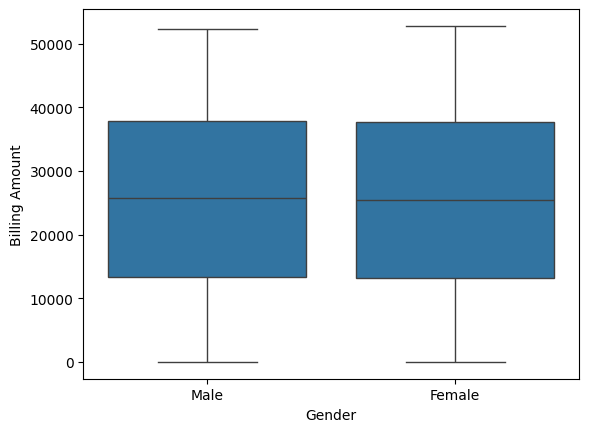

In [20]:
sns.boxplot(x='Gender', y='Billing Amount', data=df)
plt.show()

The box plot shows the billing amount distributions overlap almost completely between Male and Female patients, with no visible difference between the two.

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [16]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)